# Libraries

In [2]:
!python -c "import SimpleITK" || pip install --upgrade --pre SimpleITK --find-links https://github.com/SimpleITK/SimpleITK/releases/tag/latest --progress-bar off -q
!python -c "import matplotlib" || pip install --progress-bar off -q matplotlib
!python -c "import radiomics" || pip install --progress-bar off -q pyradiomics
!python -c "import yaml" || pip install --progress-bar off -q pyyaml
!python -c "import pandas" || pip install --progress-bar off -q pandas

In [ ]:
#import yaml
import os
import pandas as pd
import csv
from pathlib import Path
import re
import matplotlib.pyplot as plt
import matplotlib as mpl  
import seaborn as sns
import numpy as np
from radiomics import featureextractor
import concurrent.futures
import SimpleITK as sitk
import monai

In [10]:
csv_path = '/mnt/datalake/openmind/MedP-Midas/data/filtered_midas900_t2w.csv'
param_path = '/mnt/datalake/openmind/MedP-Midas/src/radiomics/Params.yaml'
input_df = pd.read_csv(csv_path)

## Image size

In [3]:
os.makedirs("/mnt/datalake/openmind/MedP-Midas/data/datos_intermedios", exist_ok=True)


rows = []

for idx, ruta in enumerate(input_df['Image']):
    try:
        img = sitk.ReadImage(ruta)
        w, h, d = img.GetSize()
        rows.append({
            "ID": input_df.loc[idx, 'ID'],
            "image_width": w,
            "image_height": h,
            "image_depth": d
        })
    except Exception as e:
        print(f"Error con la imagen {ruta}: {e}")

df = pd.DataFrame(rows)
df.to_csv("/mnt/datalake/openmind/MedP-Midas/data/datos_intermedios/image_dimensions.csv", index=False)
df.head()

,ID,image_width,image_height,image_depth
0,s_10223,512,512,12
1,s_10095,512,512,12
2,s_10087,512,512,12
3,s_10168,512,512,12
4,s_10067,512,512,14


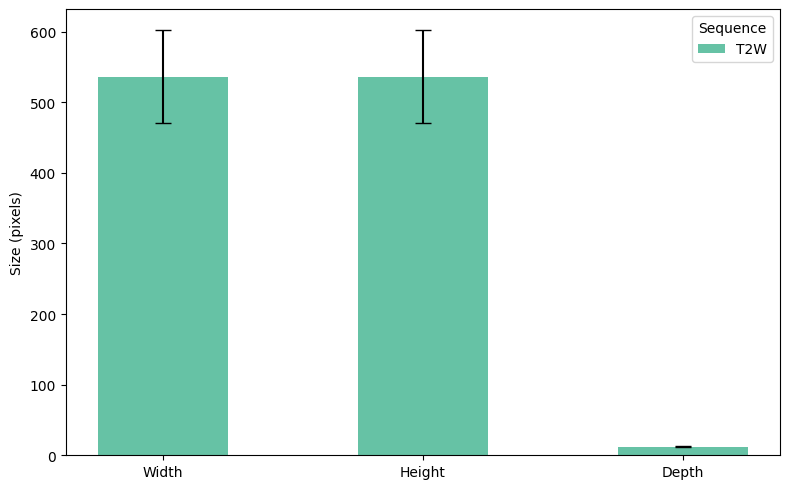

In [5]:
csv_path_dimensions = Path("/mnt/datalake/openmind/MedP-Midas/data/datos_intermedios/image_dimensions.csv")
df = pd.read_csv(csv_path_dimensions)

# 2. Definir secuencias y dimensiones
secuencias = ["t2w"]
dimensiones = ["width", "height", "depth"]
col_tpl = "image_{dim}"

# 3. Calcular medias y desviaciones
# Calcular medias y desviaciones para t2w
medias = [df[col_tpl.format(dim=dim)].mean() for dim in dimensiones]
desv   = [df[col_tpl.format(dim=dim)].std()  for dim in dimensiones]


# 4. Configurar la paleta color-blind-friendly
palette = sns.color_palette("Set2", n_colors=1)
colores = {"t2w": palette[0]}

# ─────────────────────────────────────────────────────────
# 5. Dibujar las barras
x = np.arange(len(dimensiones))   
ancho   = 0.5

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x,
    medias,
    ancho,
    yerr=desv,
    capsize=6,
    label="T2W",
    color=colores["t2w"]
)

# 6. Etiquetas en inglés
ax.set_xticks(x)
ax.set_xticklabels(['Width', 'Height', 'Depth'])
ax.set_ylabel('Size (pixels)')
ax.legend(title='Sequence')

fig.tight_layout()
fig.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/tamaño_t2w.png", dpi=300, bbox_inches="tight")
#save in pdf
fig.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/tamaño_t2w.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Image Size Analysis

This bar plot shows the average dimensions of T2-weighted MRI images in the dataset measured in pixels. Each bar represents:

- **Width**: Pixel count in the axial (left-right) dimension
- **Height**: Pixel count in the coronal (anterior-posterior) dimension  
- **Depth**: Number of slices in the sagittal (superior-inferior) dimension

**Key Observations:**
- The images show relatively consistent dimensions across the dataset (small error bars indicate low variability)
- Width and height dimensions are similar, suggesting approximately square axial slices
- The depth dimension represents the number of 2D slices that comprise each 3D volume
- This dimensional consistency is important for radiomics feature extraction as it ensures comparable spatial sampling across all subjects

**Clinical Relevance**: Standardized image dimensions facilitate consistent radiomics analysis and ensure that extracted features are comparable across different patients and acquisition protocols.

## Spacing image


In [6]:
input_df = pd.read_csv(csv_path)
rows = []

for idx, ruta in enumerate(input_df['Image']):
    try:
        img = sitk.ReadImage(ruta)
        esp_x, esp_y, esp_z = img.GetSpacing()
        rows.append({
            "ID": input_df.loc[idx, 'ID'],
            "t2w_spac_x": esp_x,
            "t2w_spac_y": esp_y,
            "t2w_spac_z": esp_z
        })
    except Exception as e:
        print(f"Error con la imagen {ruta}: {e}")

df = pd.DataFrame(rows)
df.to_csv("/mnt/datalake/openmind/MedP-Midas/data/datos_intermedios/image_spacing.csv", index=False)
df.head()

,ID,t2w_spac_x,t2w_spac_y,t2w_spac_z
0,s_10223,0.644531,0.644526,5.999982
1,s_10095,0.585938,0.585943,5.499995
2,s_10087,0.585938,0.585934,5.500022
3,s_10168,0.585938,0.585938,5.800040
4,s_10067,0.585938,0.585938,5.500000


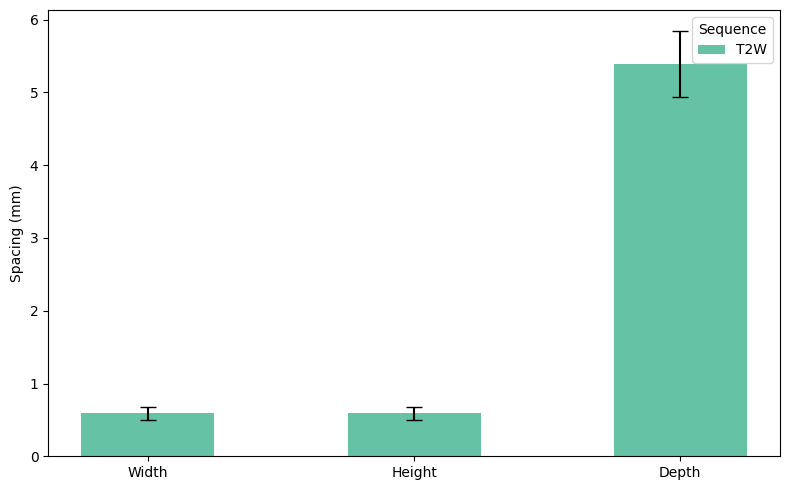

[0.5900618276835485, 0.5900616403902924, 5.386819155146387]


In [7]:
# 1. Cargar CSV de espaciados
df = pd.read_csv("/mnt/datalake/openmind/MedP-Midas/data/datos_intermedios/image_spacing.csv")

# 2. Definir ejes (solo t2w)
ejes = ["spac_x", "spac_y", "spac_z"]
col_tpl = "t2w_{eje}"

# 3. Calcular medias y desviaciones para t2w
medias = [df[col_tpl.format(eje=eje)].mean() for eje in ejes]
desv   = [df[col_tpl.format(eje=eje)].std()  for eje in ejes]

# 4. Paleta colorblind-friendly
color = sns.color_palette("Set2", n_colors=1)[0]

# 5. Dibujar barras
x = np.arange(len(ejes))
ancho = 0.5

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    x,
    medias,
    ancho,
    yerr=desv,
    capsize=6,
    label="T2W",
    color=color
)

# 6. Etiquetas en inglés
ax.set_xticks(x)
ax.set_xticklabels(['Width', 'Height', 'Depth'])
ax.set_ylabel('Spacing (mm)')
ax.legend(title='Sequence')

fig.tight_layout()
fig.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/espaciado_t2w.png", dpi=300, bbox_inches="tight")
#save in pdf
fig.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/espaciado_t2w.pdf", dpi=300, bbox_inches="tight")
plt.show()
print(medias)

## Label + image visualization


In [3]:
csv_path = "/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/output.csv"
input_df = pd.read_csv(csv_path)

In [ ]:
for idx, row in input_df.iterrows():
    print(idx)
    print(row)
    ## see values inside the mask
    # Leer imagen y máscara
    image = sitk.ReadImage(row["Image"])
    mask = sitk.ReadImage(row["Mask"])
    # Convertir a array numpy
    image_np = sitk.GetArrayFromImage(image)
    mask_np = sitk.GetArrayFromImage(mask)
    # #rotate the image and mask 180 degrees around the z axis
    # image_np = np.rot90(image_np, k=2, axes=(1, 2))
    # mask_np = np.rot90(mask_np, k=2, axes=(1, 2))

    print("Valores únicos en la máscara original:", np.unique(mask_np))
    

Procesando imagen: /mnt/datalake/openmind/Midas/datasets/Midas_V0_merge_dep_fixed/MIDASds01/sub-S0017845/ses-E0019195/mim-mr/anat/sub-S0017845_ses-E0019195_run-1_bp-lsspine_vp-sag_T2w.nii.gz
Procesando máscara: /mnt/datalake/openmind/Midas/datasets/Midas_V0_merge_dep_fixed/MIDASds01/derivatives/aut_seg/sub-S0017845/ses-E0019195/mod-mr/anat/sub-S0017845_ses-E0019195_run-1_bp-lsspine_vp-sag_T2w_discs.nii.gz
Procesando imagen: /mnt/datalake/openmind/Midas/datasets/Midas_V0_merge_dep_fixed/MIDASds01/sub-S0017845/ses-E0019195/mim-mr/anat/sub-S0017845_ses-E0019195_run-1_bp-lsspine_vp-sag_T2w.nii.gz
Valores únicos en la máscara original: [0 1 2 3 4 5 6 7 8]
Valores únicos en la máscara filtrada (1-5): [0 1 2 3 4 5]


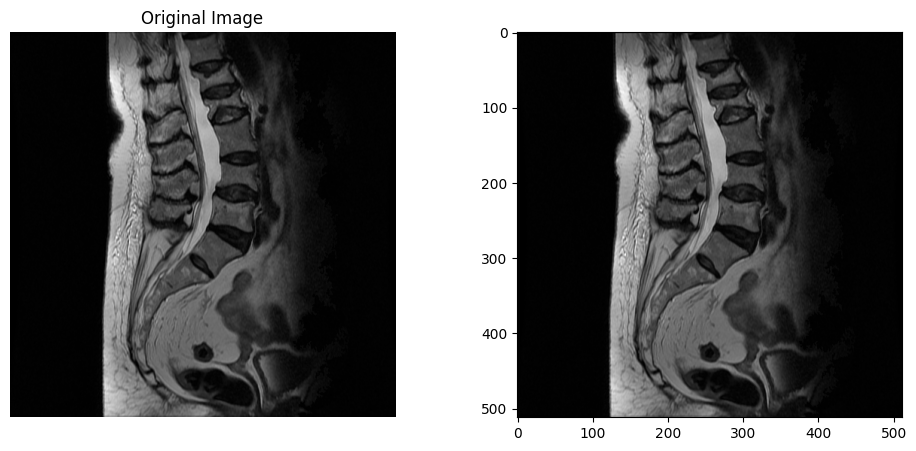

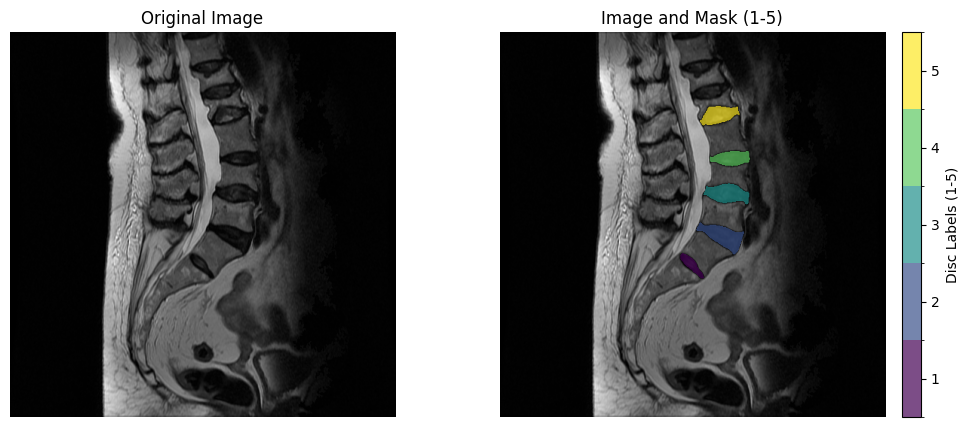

In [ ]:
# Cambia el índice para ver diferentes pacientes
for idx, row in input_df.iterrows():
    if idx == 5:  # Cambia el índice para ver diferentes pacientes
        
        image_path = row["Image"]
        mask_path = row["Mask"]


        # Leer imagen y máscara
        # image = sitk.ReadImage(image_path)
        # mask = sitk.ReadImage(mask_path)
        image = sitk.ReadImage("/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T2.nii.gz")
        mask = sitk.ReadImage("/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/derivatives/aut_seg/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T1_disc_discs_clean.nii.gz")


        # Convertir a array numpy
        image_np = sitk.GetArrayFromImage(image)
        mask_np = sitk.GetArrayFromImage(mask)
        #rotate the image and mask 180 degrees around the z axis
        image_np = np.rot90(image_np, k=2, axes=(1, 2))
        mask_np = np.rot90(mask_np, k=2, axes=(1, 2))

        print("Valores únicos en la máscara original:", np.unique(mask_np))
        # image_np = sitk.PermuteAxes(image_np, [0,1,2])
        # image_np = sitk.Flip(image_np, [True, True, False])
                
        # Filtrar máscara para mostrar solo etiquetas 1-5
        mask_filtered = mask_np.copy()
        mask_filtered[(mask_np < 1) | (mask_np > 5)] = 0
        print("Valores únicos en la máscara filtrada (1-5):", np.unique(mask_filtered))

        # Seleccionar un corte central
        slice_idx = image_np.shape[0] // 2

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image_np[slice_idx], cmap="gray")
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        # Aplicar filtro gris (reducir contraste) a la imagen de fondo
        image_filtered = image_np[slice_idx] * 0.6  # Reducir intensidad para efecto gris
        plt.imshow(image_filtered, cmap="gray")
        import matplotlib.colors as mcolors



# Mostrar solo etiquetas 1-5 con colormap discreto
mask_to_show = mask_filtered[slice_idx].astype(float)
mask_to_show[mask_to_show == 0] = np.nan  # Hacer transparentes los valores 0

# Obtener las etiquetas presentes (sin el fondo)
labels_present = np.unique(mask_filtered[slice_idx])
labels_present = labels_present[(labels_present >= 1) & (labels_present <= 5)]

# Crear un colormap discreto solo para las etiquetas presentes
cmap = mcolors.ListedColormap(plt.cm.viridis(np.linspace(0, 1, 5))[labels_present - 1])
norm = mcolors.BoundaryNorm(boundaries=np.append(labels_present - 0.5, labels_present[-1] + 0.5), ncolors=len(labels_present))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_np[slice_idx], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
image_filtered = image_np[slice_idx] * 0.6
plt.imshow(image_filtered, cmap="gray")
im_mask = plt.imshow(mask_to_show, cmap=cmap, norm=norm, alpha=0.7)
plt.title("Image and Mask (1-5)")
plt.axis("off")

# Añadir colorbar discreta solo con las etiquetas presentes
cbar = plt.colorbar(im_mask, ticks=labels_present, fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels([str(int(l)) for l in labels_present])
cbar.set_label('Disc Labels (1-5)')

# plt.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/image_mask_example.png", bbox_inches='tight')
# plt.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/image_mask_example.pdf", bbox_inches='tight')

In [ ]:
#sofia
image = sitk.ReadImage("/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T2.nii.gz")
mask = sitk.ReadImage("/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/derivatives/aut_seg/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T1_disc_discs_clean.nii.gz")
#mora
# image = sitk.ReadImage("/mnt/datalake/openmind/Midas/datasets/Midas_V0_merge_dep_fixed/MIDASds07/sub-S0017004/ses-E0018347/mim-mr/anat/sub-S0017004_ses-E0018347_acq1_run-1_bp-spine_vp-ax_T2w.nii.gz")
# mask = sitk.ReadImage("/mnt/datalake/openmind/Midas/datasets/Midas_V0_merge_dep_fixed/MIDASds07/derivatives/aut_seg/sub-S0017004/ses-E0018347/mod-mr/anat/sub-S0017004_ses-E0018347_run-1_bp-lsspine_vp-sag_T2w_discs.nii.gz")

# Convertir a array numpy
image_np = sitk.GetArrayFromImage(image)
mask_np = sitk.GetArrayFromImage(mask)
# #rotate the image and mask 180 degrees around the z axis
# image_np = np.rot90(image_np, k=2, axes=(1, 2))
# mask_np = np.rot90(mask_np, k=2, axes=(1, 2))

print("Valores únicos en la máscara original:", np.unique(mask_np))

Valores únicos en la máscara original: [0. 1. 2. 3. 4. 5.]
Valores únicos en la máscara filtrada (1-5): [0. 1. 2. 3. 4. 5.]
[0. 1. 2. 3. 4. 5.]


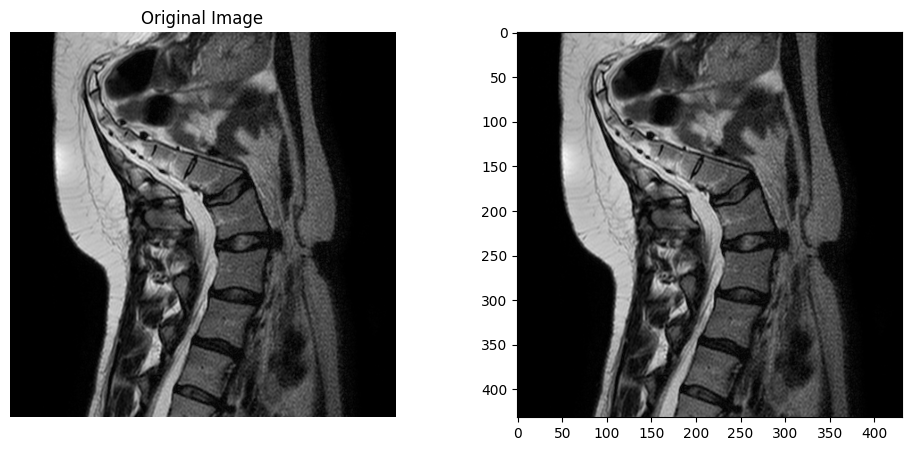

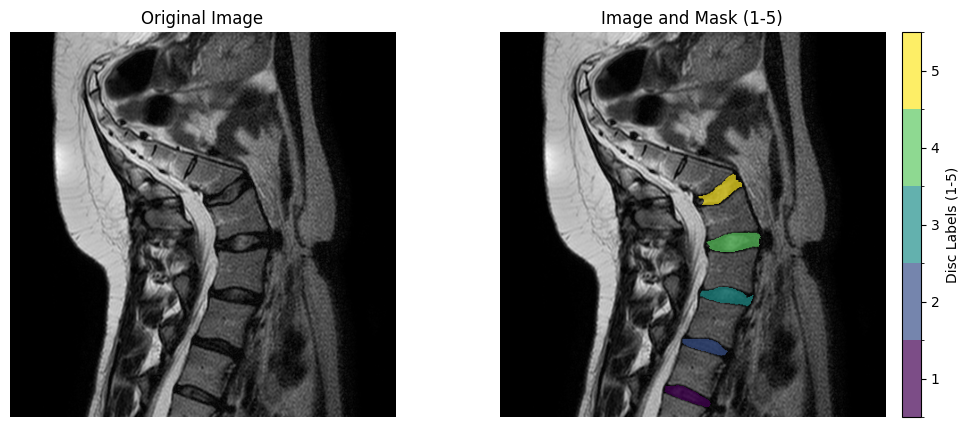

In [ ]:
# Leer imagen y máscara
image = sitk.ReadImage("/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T2.nii.gz")
mask = sitk.ReadImage("/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/derivatives/aut_seg/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T1_disc_discs_clean.nii.gz")


# Convertir a array numpy
image_np = sitk.GetArrayFromImage(image)
mask_np = sitk.GetArrayFromImage(mask)
#rotate the image and mask 180 degrees around the z axis
image_np = np.rot90(image_np, k=2, axes=(1, 2))
mask_np = np.rot90(mask_np, k=2, axes=(1, 2))

print("Valores únicos en la máscara original:", np.unique(mask_np))
# image_np = sitk.PermuteAxes(image_np, [0,1,2])
# image_np = sitk.Flip(image_np, [True, True, False])
        
# Filtrar máscara para mostrar solo etiquetas 1-5
mask_filtered = mask_np.copy()
mask_filtered[(mask_np < 1) | (mask_np > 5)] = 0
print("Valores únicos en la máscara filtrada (1-5):", np.unique(mask_filtered))

# Seleccionar un corte central
slice_idx = image_np.shape[0] // 2

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_np[slice_idx], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# Aplicar filtro gris (reducir contraste) a la imagen de fondo
image_filtered = image_np[slice_idx] * 0.6  # Reducir intensidad para efecto gris
plt.imshow(image_filtered, cmap="gray")



# Mostrar solo etiquetas 1-5 con colormap discreto
mask_to_show = mask_filtered[slice_idx].astype(float)
mask_to_show[mask_to_show == 0] = np.nan  # Hacer transparentes los valores 0

# Obtener las etiquetas presentes (sin el fondo)
labels_present = np.unique(mask_filtered[slice_idx])
print(labels_present)
#convert to int
labels_present = labels_present.astype(int)
labels_present = labels_present[(labels_present >= 1) & (labels_present <= 5)]

# Crear un colormap discreto solo para las etiquetas presentes
cmap = mcolors.ListedColormap(plt.cm.viridis(np.linspace(0, 1, 5))[labels_present - 1])
norm = mcolors.BoundaryNorm(boundaries=np.append(labels_present - 0.5, labels_present[-1] + 0.5), ncolors=len(labels_present))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_np[slice_idx], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
image_filtered = image_np[slice_idx] * 0.6
plt.imshow(image_filtered, cmap="gray")
im_mask = plt.imshow(mask_to_show, cmap=cmap, norm=norm, alpha=0.7)
plt.title("Image and Mask (1-5)")
plt.axis("off")

# Añadir colorbar discreta solo con las etiquetas presentes
cbar = plt.colorbar(im_mask, ticks=labels_present, fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels([str(int(l)) for l in labels_present])
cbar.set_label('Disc Labels (1-5)')

# plt.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/image_mask_example.png", bbox_inches='tight')
# plt.savefig("/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/image_mask_example.pdf", bbox_inches='tight')

In [13]:
import SimpleITK as sitk
import os

def crop_and_save_discs(image_path, mask_path, output_dir, padding=(10, 10, 0)):
    """
    Crops individual discs from a spine MRI based on a multiclass mask.
    """
    # 1. Load Image and Mask
    image = sitk.ReadImage(image_path)
    mask = sitk.ReadImage(mask_path)

    mask = sitk.Cast(mask, sitk.sitkUInt8)

    # 2. Define the Mapping (Adjust based on your specific model's output)
    # Example: Assuming 1 is L1-L2 and proceeding downwards
    disc_map = {
        1: "L1-L2",
        2: "L2-L3",
        3: "L3-L4",
        4: "L4-L5",
        5: "L5-S1"
    }

    # 3. Calculate Bounding Boxes using LabelShapeStatistics
    stats = sitk.LabelShapeStatisticsImageFilter()
    stats.Execute(mask)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print(f"Processing: {os.path.basename(image_path)}")

    # 4. Loop through expected discs and crop
    for label_id, disc_name in disc_map.items():
        if stats.HasLabel(label_id):
            # Get bounding box: (x_start, y_start, z_start, x_size, y_size, z_size)
            bbox = stats.GetBoundingBox(label_id)
            
            # --- Calculate Padding (Safe Cropping) ---
            # We convert bbox to list to modify it
            start = list(bbox[:3])
            size = list(bbox[3:])
            
            img_size = image.GetSize()

            for i in range(3): # x, y, z dimensions
                # Subtract padding from start (ensure not < 0)
                start[i] = max(0, start[i] - padding[i])
                # Add padding to size (original size + 2*padding), ensure not > image size
                # We need to calculate the new end point to check bounds
                end_pos = min(img_size[i], start[i] + size[i] + (2 * padding[i]))
                size[i] = end_pos - start[i]

            # --- Perform the Crop ---
            # RegionOfInterest takes (size, index)
            cropped_image = sitk.RegionOfInterest(image, size=size, index=start)
            
            # Save the file
            out_name = os.path.join(output_dir, f"sub-S02_{disc_name}.nii.gz")
            sitk.WriteImage(cropped_image, out_name)
            print(f"  -> Saved {disc_name} (Label {label_id})")
        else:
            print(f"  -> Warning: Label {label_id} ({disc_name}) not found in mask.")

# --- USAGE ---
img_path = "/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T2.nii.gz"
msk_path = "/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/Ceib/derivatives/aut_seg/sub-S02/ses-E02/mod-mr/anat/sub-S02_ses-E02_Sag_T1_disc_discs_clean.nii.gz"
out_path = "/mnt/datalake/openmind/Midas/training_wheels_Spine/lib/my_lib/segmentation_nets/predict_nii_up/patients_midas/cropped_discs/"

crop_and_save_discs(img_path, msk_path, out_path)

Processing: sub-S02_ses-E02_Sag_T2.nii.gz
  -> Saved L1-L2 (Label 1)
  -> Saved L2-L3 (Label 2)
  -> Saved L3-L4 (Label 3)
  -> Saved L4-L5 (Label 4)
  -> Saved L5-S1 (Label 5)


## MONAI visualization specific case

### Explanation: Square Shape Issue in Mask Visualization

The square appearance in the mask visualization occurs due to several factors:

1. **Colormap Range**: When using `cmap="viridis"` without proper `vmin` and `vmax` parameters, matplotlib automatically scales the colormap to the full range of values present in the data, which can create artificial visual boundaries.

2. **Alpha Transparency**: The combination of transparency settings and colormap scaling can create visual artifacts that appear as geometric shapes.

3. **NaN Handling**: The way matplotlib handles NaN values (transparent pixels) in combination with the colormap can create edge effects.

4. **Aspect Ratio**: The default aspect ratio settings might not preserve the original image proportions.

**Solutions to improve visualization:**
- Set explicit `vmin=1, vmax=5` to control colormap range
- Adjust `alpha` transparency values
- Use `aspect='equal'` to maintain proper proportions
- Consider using discrete colormaps for categorical data (disc labels)

In [ ]:
image_path = input_df["Image"][1]
mask_path = input_df["Mask"][1]

image = monai.transforms.LoadImage(image_only=True, ensure_channel_first=True)(image_path)
label = monai.transforms.LoadImage(image_only=True, ensure_channel_first=True)(mask_path)
label[label < 6] = 0
print(f"Imagen: {image.shape}, Máscara: {label.shape}")

Imagen: torch.Size([1, 512, 512, 12]), Máscara: torch.Size([1, 512, 512, 12])


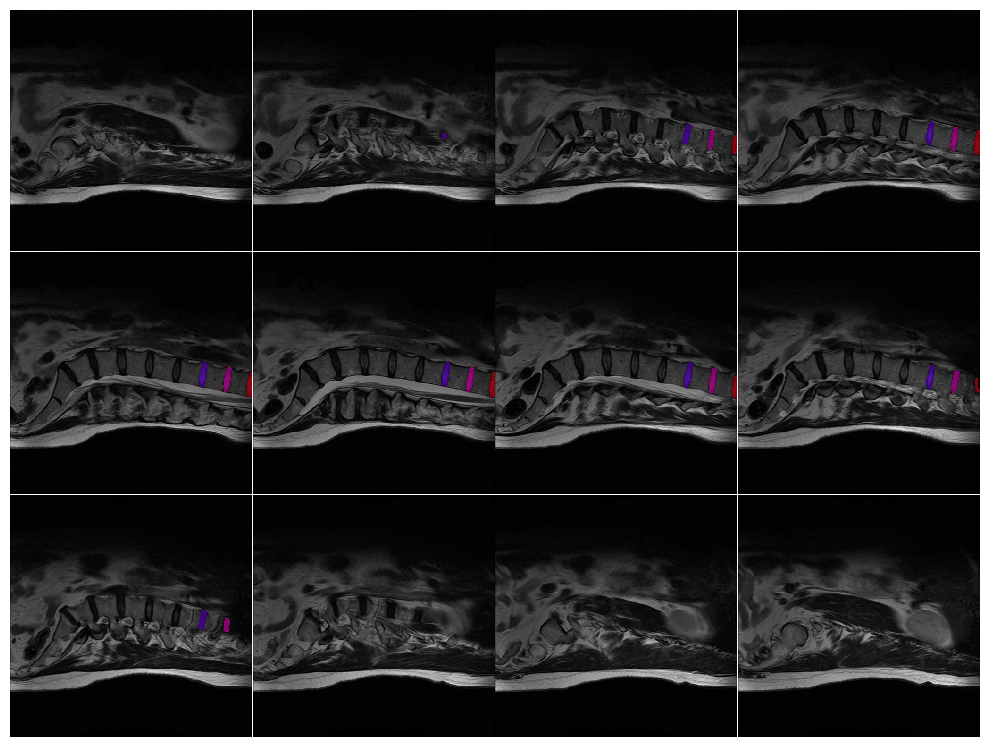

In [ ]:
blended = monai.visualize.utils.blend_images(image, label)
monai.visualize.matshow3d(blended, frame_dim=-1, channel_dim=0, show=True)
plt.show()

In [9]:
import pandas as pd
import numpy as np

# Leer el archivo CSV
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/data/filtered_midas900_t2w_partition.csv')

print('=== DISTRIBUCIÓN DE GRADOS PFIRRMANN POR NIVEL DE DISCO ===')
print(f'Total de sujetos: {len(df)}')
print()

# Mapeo de columnas a niveles de disco
disc_mapping = {
    '1': 'L5-S1',
    '2': 'L4-L5', 
    '3': 'L3-L4',
    '4': 'L2-L3',
    '5': 'L1-L2'
}

# Análisis por cada nivel
for col_num, disc_name in disc_mapping.items():
    print(f'📊 DISCO {disc_name} (columna {col_num}):')
    # Filtrar valores no nulos
    valid_values = df[col_num].dropna()
    conteo = valid_values.value_counts().sort_index()
    
    total_valid = len(valid_values)
    print('Grado | Cantidad | Porcentaje')
    print('------|----------|----------')
    for grade in sorted(conteo.index):
        count = conteo[grade]
        percent = (count / total_valid) * 100
        print(f'  {int(grade)}   |   {count:3d}    |   {percent:5.1f}%')
    
    print(f'   Total válido: {total_valid}')
    print(f'   Valores faltantes: {len(df) - total_valid}')
    print()

# Análisis global de todos los discos
print('📊 DISTRIBUCIÓN GLOBAL (TODOS LOS DISCOS):')
all_grades = []
for col_num in ['1', '2', '3', '4', '5']:
    valid_values = df[col_num].dropna()
    all_grades.extend(valid_values.tolist())

if all_grades:
    grades_series = pd.Series(all_grades)
    global_counts = grades_series.value_counts().sort_index()
    total_discos = len(all_grades)

    print('Grado | Cantidad | Porcentaje')
    print('------|----------|----------')
    for grade in sorted(global_counts.index):
        count = global_counts[grade]
        percent = (count / total_discos) * 100
        print(f'  {int(grade)}   |   {count:3d}    |   {percent:5.1f}%')

    print(f'\\nTotal de discos evaluados: {total_discos}')
    print(f'Total de sujetos: {len(df)}')
    print(f'Discos por sujeto (promedio): {total_discos/len(df):.1f}')
else:
    print('No se encontraron datos válidos')


=== DISTRIBUCIÓN DE GRADOS PFIRRMANN POR NIVEL DE DISCO ===
Total de sujetos: 717

📊 DISCO L5-S1 (columna 1):
Grado | Cantidad | Porcentaje
------|----------|----------
  1   |    13    |     1.8%
  2   |    38    |     5.3%
  3   |   193    |    26.9%
  4   |   380    |    53.0%
  5   |    93    |    13.0%
   Total válido: 717
   Valores faltantes: 0

📊 DISCO L4-L5 (columna 2):
Grado | Cantidad | Porcentaje
------|----------|----------
  1   |    14    |     2.0%
  2   |    51    |     7.1%
  3   |   190    |    26.5%
  4   |   416    |    58.0%
  5   |    46    |     6.4%
   Total válido: 717
   Valores faltantes: 0

📊 DISCO L3-L4 (columna 3):
Grado | Cantidad | Porcentaje
------|----------|----------
  1   |    19    |     2.6%
  2   |    91    |    12.7%
  3   |   300    |    41.8%
  4   |   284    |    39.6%
  5   |    23    |     3.2%
   Total válido: 717
   Valores faltantes: 0

📊 DISCO L2-L3 (columna 4):
Grado | Cantidad | Porcentaje
------|----------|----------
  1   |    16  

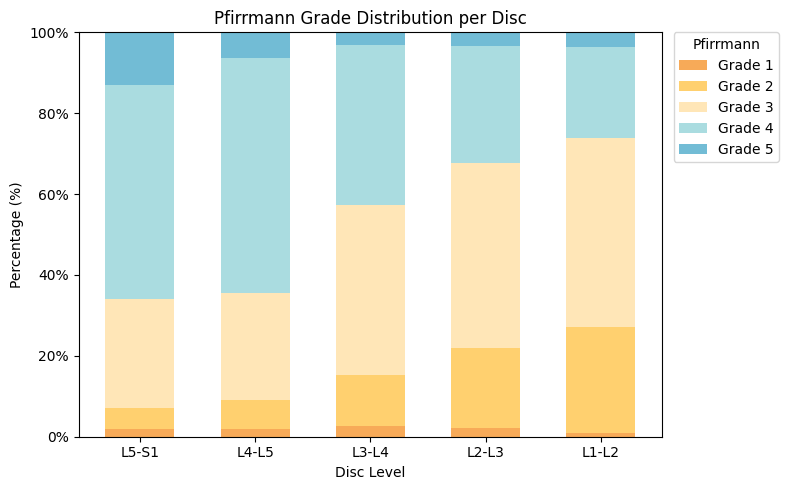

Saved: /mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/pfirrmann_per_disc_stacked_clean.png and /mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/pfirrmann_per_disc_stacked_clean.pdf


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/data/filtered_midas900_t2w_partition.csv')
for c in ['1','2','3','4','5']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

disc_mapping = {
    '1': 'L5-S1',
    '2': 'L4-L5',
    '3': 'L3-L4',
    '4': 'L2-L3',
    '5': 'L1-L2'
}
grades_all = [1,2,3,4,5]

rows = []
for col, disc_name in disc_mapping.items():
    series = df[col].dropna()
    total = len(series)
    counts = series.value_counts().reindex(grades_all, fill_value=0).sort_index()
    perc = (counts / total * 100) if total > 0 else counts.astype(float)
    for g in grades_all:
        rows.append({'Disc': disc_name, 'Grade': g, 'Percent': perc[g], 'Count': counts[g], 'Total': total})

dist_df = pd.DataFrame(rows)
pivot_df = dist_df.pivot(index='Disc', columns='Grade', values='Percent').reindex(list(disc_mapping.values()))
colors = ["#e76254", "#ef8a47", "#f7aa58", "#ffd06f", "#ffe6b7", "#aadce0", "#72bcd5", "#528fad", "#376795", "#1e466e"]
# palette = sns.color_palette("Set2", n_colors=len(grades_all))

fig, ax = plt.subplots(figsize=(8,5))
bottom = np.zeros(len(pivot_df))
bar_width = 0.6  # barras más delgadas (valor por debajo de 0.8)

for i, g in enumerate(grades_all):
    vals = pivot_df[g].fillna(0).values
    ax.bar(pivot_df.index, vals, bottom=bottom, width=bar_width,
           color=colors[i+2], label=f'Grade {g}')
    bottom += vals

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Disc Level')
ax.set_title('Pfirrmann Grade Distribution per Disc')
ax.set_ylim(0, 100)
# Legend moved to the right outside plot
ax.legend(title='Pfirrmann', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x)}%')

# Removed n= counts below x-axis

plt.tight_layout()
out_dir_png = "/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/pfirrmann_per_disc_stacked_clean.png"
out_dir_pdf = "/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/images_EDA/pfirrmann_per_disc_stacked_clean.pdf"
plt.savefig(out_dir_png, dpi=300, bbox_inches='tight')
plt.savefig(out_dir_pdf, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {out_dir_png} and {out_dir_pdf}")

## Pfirrmann Binary EDA

In [ ]:
# Carga tu archivo binarizado (ajusta la ruta si es necesario)
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/binary/features_t2w_label1_with_pfirrmann_binary.csv')

# Nombres reales de los discos
disc_real_names = {
    '1': 'L5-S',
    '2': 'L4-L5',
    '3': 'L3-L4',
    '4': 'L2-L3',
    '5': 'L1-L2'
}
cols_discos = ['1', '2', '3', '4', '5']

# --- Gráfico 1: Barras para cada disco (binario) ---
fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, col in enumerate(cols_discos):
    sns.countplot(x=df[col], ax=axs[i], palette="viridis", hue=df[col], legend=False)
    axs[i].set_title(f'Disco {i+1} ({disc_real_names[col]})')
    axs[i].set_xlabel('Pfirrmann binario')
    axs[i].set_ylabel('Frecuencia' if i == 0 else '')
plt.suptitle('Distribución binaria de Pfirrmann por disco')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Gráfico 2: Barras del total de grados (todos los discos juntos, binario) ---
all_grades_bin = pd.concat([df[c] for c in cols_discos])
plt.figure(figsize=(6, 4))
sns.countplot(x=all_grades_bin, palette="magma")
plt.title('Conteo total de Pfirrmann binario (todos los discos)')
plt.xlabel('Pfirrmann binario')
plt.ylabel('Frecuencia')
plt.show()

# --- Gráfico 3: Pacientes con al menos un disco Pfirrmann 4-5 (binario=1) ---
pacientes_con_grado1 = df[cols_discos].eq(1).any(axis=1)
labels = ['Al menos un disco 4-5', 'Todos los discos 1-3']
sizes = [pacientes_con_grado1.sum(), len(df) - pacientes_con_grado1.sum()]
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ff6666', '#66b3ff'])
plt.title('Pacientes con al menos un disco Pfirrmann 4-5')
plt.show()

## Pfirrmann Multiclass EDA


In [ ]:
# Carga el archivo combinado
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/data/merged_labels_with_pfirrmann.csv')

# Análisis 1: Conteo de valores únicos para cada disco (1-5) #english
for col in ['1', '2', '3', '4', '5']:
    print(f"Unique Pfirrmann grades count for disc {col}:")
    print(df[col].value_counts(dropna=False))
    print()

# Análisis 2: Estadísticas descriptivas generales english
print("General descriptive statistics of Pfirrmann grades:")
print(df[['1', '2', '3', '4', '5']].describe())

# Análisis 3: Conteo total de cada grado (sumando todos los discos)
all_grades = pd.concat([df['1'], df['2'], df['3'], df['4'], df['5']])
print("Total count of each Pfirrmann grade across all discs:")
print(all_grades.value_counts(dropna=False))

# Análisis 4: ¿Cuántos pacientes tienen al menos un disco con grado 5?
pacientes_con_grado5 = df[(df[['1', '2', '3', '4', '5']] == 5).any(axis=1)]
print(f"NNumber of patients with at least one disc grade 5: {len(pacientes_con_grado5)}")

In [ ]:
# Carga el archivo combinado #English
df = pd.read_csv('/mnt/datalake/openmind/MedP-Midas/data/merged_labels_with_pfirrmann.csv')

# --- Gráfico 1: Barras para cada disco ---
fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, col in enumerate(['1', '2', '3', '4', '5']):
    sns.countplot(x=df[col], ax=axs[i], palette="viridis", hue=df[col], legend=False)
    axs[i].set_title(f'Disc {col}')
    axs[i].set_xlabel('Pfirrmann Grade')
    axs[i].set_ylabel('Frequency' if i == 0 else '')
plt.suptitle('Distribution of Pfirrmann grades by disc')
plt.tight_layout(rect=[0, 0, 1, 0.95])
#save as pdf and png
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/distribution_pfirrmann_grades_by_disc.pdf', bbox_inches='tight')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/distribution_pfirrmann_grades_by_disc.png', bbox_inches='tight')
plt.show()
# --- Gráfico 2: Boxplot de los grados por disco ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['1', '2', '3', '4', '5']])
plt.title('Boxplot of Pfirrmann grades by disc')
plt.xlabel('Disc')
plt.ylabel('Pfirrmann Grade')
#save as pdf and png
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/boxplot_by_disc.pdf', bbox_inches='tight')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/boxplot_by_disc.png', bbox_inches='tight')
plt.show()
# --- Gráfico 3: Barras del total de grados (todos los discos juntos) ---
all_grades = pd.concat([df['1'], df['2'], df['3'], df['4'], df['5']])
plt.figure(figsize=(6, 4))
sns.countplot(x=all_grades, palette="magma")
plt.title('Total count of each Pfirrmann grade (all discs)')
plt.xlabel('Pfirrmann Grade')
plt.ylabel('Frequency')
#save as pdf and png
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/total_count.pdf', bbox_inches='tight')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/total_count.png', bbox_inches='tight')
plt.show()
# --- Gráfico 4: Pacientes con al menos un disco grado 5 ---
pacientes_con_grado5 = df[(df[['1', '2', '3', '4', '5']] == 5).any(axis=1)]
labels = ['With grade 5', 'Without grade 5']
sizes = [len(pacientes_con_grado5), len(df) - len(pacientes_con_grado5)]
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ff6666', '#66b3ff'])
plt.title('Patients with at least one disc grade 5')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/patients_with_grade5.pdf', bbox_inches='tight')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/patients_with_grade5.png', bbox_inches='tight')
plt.show()

# --- Gráfico 4: Pacientes con al menos un disco grado 1 ---
pacientes_con_grado1 = df[(df[['1', '2', '3', '4', '5']] == 1).any(axis=1)]
labels = ['With grade 1', 'Without grade 1']
sizes = [len(pacientes_con_grado1), len(df) - len(pacientes_con_grado1)]
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ff6666', '#66b3ff'])
plt.title('Patients with at least one disc grade 1')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/patients_with_grade1.pdf', bbox_inches='tight')
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/patients_with_grade1.png', bbox_inches='tight')
plt.show()

In [ ]:


# Ruta al archivo CSV
df_path = '/mnt/datalake/openmind/MedP-Midas/data/filtered_midas900_t2w_partition.csv'
# Cargar datos
df = pd.read_csv(df_path)

# Mapeo de columnas numéricas a nombres de niveles de disco IN ENGLISH
disc_mapping = {
    '1': 'L5-S1',
    '2': 'L4-L5',
    '3': 'L3-L4',
    '4': 'L2-L3',
    '5': 'L1-L2'
}

# Transformar a formato largo (melt)
df_long = (
    df[list(disc_mapping.keys())]
    .rename(columns=disc_mapping)
    .melt(var_name='disc_level', value_name='grade')
    .dropna()
)

# Crear tablas de conteos y porcentajes por nivel de disco
summary_counts = df_long.groupby(['disc_level', 'grade']).size().unstack(fill_value=0)
summary_percent = summary_counts.div(summary_counts.sum(axis=1), axis=0) * 100

# Mostrar tablas en consola ENGLISH
print('=== Counts by disc level ===')
print(summary_counts)
print('\n=== Percentages by disc level (rounded) ===')
print(summary_percent.round(1))

# Global analysis
global_counts = df_long['grade'].value_counts().sort_index()
global_percent = (global_counts / global_counts.sum()) * 100

print('\n=== Global distribution of grades ===')
print(pd.DataFrame({
    'Count': global_counts,
    'Percent': global_percent.round(1)
}))

# Generar gráficos
disc_levels = summary_counts.index.tolist()
num_discs = len(disc_levels)
# Preparar figura con subplots: una fila adicional para distribución global
cols = 3
rows = (num_discs + 1 + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Gráficos por nivel de disco
for i, disc in enumerate(disc_levels):
    ax = axes[i]
    summary_counts.loc[disc].plot(kind='bar', ax=ax)
    ax.set_title(f'Disc {disc}')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Count')

# Gráfico global en el siguiente subplot
ax_global = axes[len(disc_levels)]
global_counts.plot(kind='bar', ax=ax_global)
ax_global.set_title('Global Distribution')
ax_global.set_xlabel('Grade')
ax_global.set_ylabel('Count')

# Eliminar ejes sobrantes si hay
for j in range(len(disc_levels) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('/mnt/datalake/openmind/MedP-Midas/sgonzalez/radiomics-midas-new/figures/distribution_pfirrmann.png', bbox_inches='tight')